In [29]:
import pandas as pd

df = pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\Explainable-Credit-Risk-System\\data\\processed\\preprocessed_v2_encoded.csv")

print(df.shape)
df.head()

(307507, 209)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,...,0,0,0,0,0,0,0,0,0,0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225.0,...,0,0,0,0,0,0,0,0,0,0
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039.0,...,0,0,0,0,0,0,0,0,0,0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038.0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
# -----------------------------
# Numerical Features
# -----------------------------
numeric_features = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "EMPLOYMENT_AGE_RATIO"
]

# -----------------------------
# Binary Features
# -----------------------------
binary_features = [
    "CODE_GENDER_M",
    "FLAG_OWN_CAR_Y",
    "FLAG_OWN_REALTY_Y"
]

# -----------------------------
# Education Features
# -----------------------------
education_features = sorted([
    col for col in df.columns
    if col.startswith("NAME_EDUCATION_TYPE_")
])

# -----------------------------
# Income Type Features
# Remove Maternity Leave
# -----------------------------
income_features = sorted([
    col for col in df.columns
    if col.startswith("NAME_INCOME_TYPE_")
    and "Maternity leave" not in col
])

# -----------------------------
# Family Status Features
# Remove Unknown
# -----------------------------
family_features = sorted([
    col for col in df.columns
    if col.startswith("NAME_FAMILY_STATUS_")
    and "Unknown" not in col
])

# -----------------------------
# Occupation Features
# Remove Unknown
# -----------------------------
occupation_features = sorted([
    col for col in df.columns
    if col.startswith("OCCUPATION_TYPE_")
    and "Unknown" not in col
])

# -----------------------------
# Housing Features
# -----------------------------
housing_features = sorted([
    col for col in df.columns
    if col.startswith("NAME_HOUSING_TYPE_")
])

# -----------------------------
# Final Feature List
# -----------------------------
selected_features = (
    numeric_features
    + binary_features
    + education_features
    + income_features
    + family_features
    + occupation_features
    + housing_features
)

print("=" * 60)
print(f"Total Selected Features : {len(selected_features)}")
print("=" * 60)

for feature in selected_features:
    print(feature)

Total Selected Features : 53
AGE_YEARS
EMPLOYMENT_YEARS
CNT_CHILDREN
CNT_FAM_MEMBERS
AMT_INCOME_TOTAL
AMT_CREDIT
AMT_ANNUITY
AMT_GOODS_PRICE
EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
CREDIT_INCOME_RATIO
ANNUITY_INCOME_RATIO
EMPLOYMENT_AGE_RATIO
CODE_GENDER_M
FLAG_OWN_CAR_Y
FLAG_OWN_REALTY_Y
NAME_EDUCATION_TYPE_Higher education
NAME_EDUCATION_TYPE_Incomplete higher
NAME_EDUCATION_TYPE_Lower secondary
NAME_EDUCATION_TYPE_Secondary / secondary special
NAME_INCOME_TYPE_Commercial associate
NAME_INCOME_TYPE_Pensioner
NAME_INCOME_TYPE_State servant
NAME_INCOME_TYPE_Student
NAME_INCOME_TYPE_Unemployed
NAME_INCOME_TYPE_Working
NAME_FAMILY_STATUS_Married
NAME_FAMILY_STATUS_Separated
NAME_FAMILY_STATUS_Single / not married
NAME_FAMILY_STATUS_Widow
OCCUPATION_TYPE_Cleaning staff
OCCUPATION_TYPE_Cooking staff
OCCUPATION_TYPE_Core staff
OCCUPATION_TYPE_Drivers
OCCUPATION_TYPE_HR staff
OCCUPATION_TYPE_High skill tech staff
OCCUPATION_TYPE_IT staff
OCCUPATION_TYPE_Laborers
OCCUPATION_TYPE_Low-skill Labo

In [34]:
X = df[selected_features]
y = df["TARGET"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (307507, 53)
y Shape: (307507,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (246005, 53)
Testing Set  : (61502, 53)


In [36]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE")
print("X :", X_train_smote.shape)
print("y :")
print(y_train_smote.value_counts())

After SMOTE
X : (452290, 53)
y :
TARGET
0    226145
1    226145
Name: count, dtype: int64


In [38]:
from xgboost import XGBClassifier

manual_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",

    n_estimators=400,
    learning_rate=0.07972624547422416,
    max_depth=6,
    min_child_weight=8,
    subsample=0.6040157517021167,
    colsample_bytree=0.9165925059388083,

    random_state=42,
    n_jobs=-1
)

manual_xgb.fit(
    X_train_smote,
    y_train_smote
)

print("Manual Entry Model Trained Successfully")

Manual Entry Model Trained Successfully


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_pred = manual_xgb.predict(X_test)
y_prob = manual_xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9085070404214497
Precision: 0.28194993412384717
Recall   : 0.08620342396777442
F1 Score : 0.13203763689649853
ROC AUC  : 0.7203720648070462

Confusion Matrix
[[55447  1090]
 [ 4537   428]]


In [40]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": manual_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
18,NAME_EDUCATION_TYPE_Incomplete higher,0.095153
22,NAME_INCOME_TYPE_Pensioner,0.089100
17,NAME_EDUCATION_TYPE_Higher education,0.065058
23,NAME_INCOME_TYPE_State servant,0.058659
21,NAME_INCOME_TYPE_Commercial associate,0.051049
2,CNT_CHILDREN,0.047420
19,NAME_EDUCATION_TYPE_Lower secondary,0.046403
20,NAME_EDUCATION_TYPE_Secondary / secondary special,0.038632
3,CNT_FAM_MEMBERS,0.037276
15,FLAG_OWN_CAR_Y,0.029979


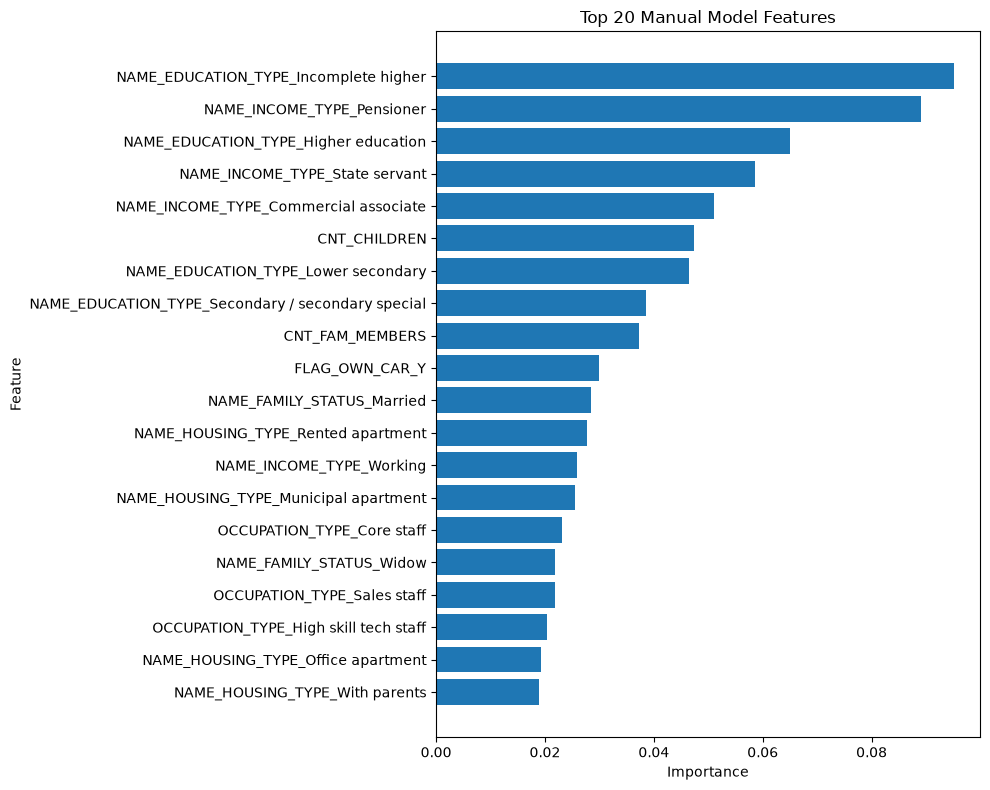

In [41]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Manual Model Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [42]:
importance[
    importance["Feature"].isin([
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "AMT_INCOME_TOTAL",
        "CREDIT_INCOME_RATIO",
        "AGE_YEARS"
    ])
].sort_values("Importance", ascending=False)

,Feature,Importance
10,EXT_SOURCE_3,0.015185
9,EXT_SOURCE_2,0.009624
0,AGE_YEARS,0.001396
4,AMT_INCOME_TOTAL,0.001022
11,CREDIT_INCOME_RATIO,0.000972


In [43]:
import joblib

joblib.dump(
    manual_xgb,
    "C:\\Users\\Asus\\OneDrive\\Desktop\\Explainable-Credit-Risk-System\\models\\manual_entry_xgb_model.joblib"
)

print("Manual model saved successfully.")

Manual model saved successfully.


In [44]:
joblib.dump(
    selected_features,
    "C:\\Users\\Asus\\OneDrive\\Desktop\\Explainable-Credit-Risk-System\\models\\manual_entry_features.joblib"
)

print("Feature list saved successfully.")

Feature list saved successfully.


In [45]:
manual_model = joblib.load(
    "C:\\Users\\Asus\\OneDrive\\Desktop\\Explainable-Credit-Risk-System\\models\\manual_entry_xgb_model.joblib"
)

manual_features = joblib.load(
    "C:\\Users\\Asus\\OneDrive\\Desktop\\Explainable-Credit-Risk-System\\models\\manual_entry_features.joblib"
)

print(type(manual_model))
print(len(manual_features))

<class 'xgboost.sklearn.XGBClassifier'>
53
